<a href="https://colab.research.google.com/github/MohamedKhalidmk/bioinformatics/blob/main/Sequence_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Programming & Sequence Alignment

In this notebook we will:
1. Understand what dynamic programming (DP) is
2. See the two key properties: **optimal substructure** and **overlapping subproblems**
3. Build a Needleman-Wunsch global alignment from scratch
4. Visualize every step of the matrix fill and traceback

---

## Part 1: What is Dynamic Programming?

Dynamic programming is a strategy for solving problems that can be broken into **smaller overlapping pieces**. It requires two properties:

- **Optimal Substructure**: The best solution to the whole problem is built from best solutions to its subproblems.
- **Overlapping Subproblems**: The same small subproblems appear again and again. Instead of re-solving them, we store results in a table.

Let's see this with a simple example first — the Fibonacci sequence — before we jump into biology.

### Naive Fibonacci (No DP)

Fibonacci is defined as: `F(n) = F(n-1) + F(n-2)`, with `F(0)=0`, `F(1)=1`.

A naive recursive approach recomputes the same values over and over. Let's count how many times each subproblem gets called.

In [ ]:
# Naive Fibonacci — notice the explosion of repeated calls

call_count = {}

def fib_naive(n):
    call_count[n] = call_count.get(n, 0) + 1
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

call_count.clear()
result = fib_naive(10)
print(f"fib(10) = {result}")
print(f"\nHow many times was each subproblem computed?")
for k in sorted(call_count.keys()):
    print(f"  fib({k}) was called {call_count[k]} times")
print(f"\nTotal function calls: {sum(call_count.values())}")

fib(10) = 55

How many times was each subproblem computed?
  fib(0) was called 34 times
  fib(1) was called 55 times
  fib(2) was called 34 times
  fib(3) was called 21 times
  fib(4) was called 13 times
  fib(5) was called 8 times
  fib(6) was called 5 times
  fib(7) was called 3 times
  fib(8) was called 2 times
  fib(9) was called 1 times
  fib(10) was called 1 times

Total function calls: 177


👆 See the problem? `fib(2)` alone gets called **34 times**. These are the **overlapping subproblems**. The same computation is done again and again.

### ⚡ Fibonacci with DP (Tabulation)

Now let's solve it bottom-up. We fill a table from small to large, and each subproblem is solved **exactly once**.

In [ ]:
# DP Fibonacci — each subproblem solved exactly once

def fib_dp(n):
    table = [0] * (n + 1)
    table[1] = 1
    for i in range(2, n + 1):
        table[i] = table[i - 1] + table[i - 2]  # uses previously stored results
    return table[n], table

result, table = fib_dp(10)
print(f"fib(10) = {result}")
print(f"DP table: {table}")
print(f"Total computations: {len(table) - 2}  (vs 177 calls in naive version)")

fib(10) = 55
DP table: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
Total computations: 9  (vs 177 calls in naive version)


That's the core idea of DP:
- **Optimal substructure**: `F(n)` is optimally built from `F(n-1)` and `F(n-2)`.
- **Overlapping subproblems**: `F(n-1)` and `F(n-2)` share sub-computations like `F(n-3)`.
- **Table storage**: We compute each value once and look it up for free after that.

Now let's apply the exact same logic to biology.

---

## Part 2: Why Sequences Need Alignment

Suppose we have two DNA sequences:

Sequence 1: ATCGT

Sequence 2: ACGT

They look similar but aren't the same length. Where's the difference? Was there a deletion? An insertion? A substitution? **Alignment** answers this by finding the best way to line them up, allowing gaps where needed.

But how many possible alignments are there? The number grows **exponentially** with sequence length. We can't try them all. This is where DP saves us.

## Part 3: Needleman-Wunsch (Global Alignment)

The Needleman-Wunsch algorithm finds the **optimal global alignment** of two sequences using DP.

### Setup
- **Match score**: reward for two identical characters (e.g., +1)
- **Mismatch penalty**: cost for two different characters (e.g., -1)
- **Gap penalty**: cost for inserting a gap (e.g., -2)

### The DP Properties in Alignment

**Optimal substructure**: The best alignment of sequences `S[1..i]` and `T[1..j]` is built from the best alignments of shorter prefixes:
- `S[1..i-1]` vs `T[1..j-1]` (match/mismatch)
- `S[1..i-1]` vs `T[1..j]` (gap in T)
- `S[1..i]` vs `T[1..j-1]` (gap in S)

**Overlapping subproblems**: The alignment of `S[1..3]` vs `T[1..2]` is needed by multiple larger alignments — `S[1..4]` vs `T[1..2]`, `S[1..3]` vs `T[1..3]`, etc.

Let's build it step by step.

### Step 1: Initialize the scoring matrix

We create a matrix with dimensions `(len(seq1)+1) x (len(seq2)+1)`. The extra row and column represent aligning against an empty sequence (all gaps).

In [ ]:
import numpy as np

# Our two sequences
seq1 = "ATCGT"
seq2 = "ACGT"

# Scoring scheme
match_score = 1
mismatch_score = -1
gap_penalty = -2

# Matrix dimensions
rows = len(seq1) + 1
cols = len(seq2) + 1

# Initialize score matrix and traceback matrix
score_matrix = np.zeros((rows, cols), dtype=int)
traceback = np.full((rows, cols), '', dtype=object)

# Fill first column: aligning seq1[0..i] against empty = i gaps
for i in range(rows):
    score_matrix[i][0] = i * gap_penalty
    traceback[i][0] = 'U'  # Up (gap in seq2)

# Fill first row: aligning empty against seq2[0..j] = j gaps
for j in range(cols):
    score_matrix[0][j] = j * gap_penalty
    traceback[0][j] = 'L'  # Left (gap in seq1)

traceback[0][0] = '*'  # origin

print("Sequences:")
print(f"  Seq1 (top→bottom): {seq1}")
print(f"  Seq2 (left→right): {seq2}")
print(f"\nScoring: match={match_score}, mismatch={mismatch_score}, gap={gap_penalty}")
print(f"\nInitialized matrix:\n{score_matrix}")

Sequences:
  Seq1 (top→bottom): ATCGT
  Seq2 (left→right): ACGT

Scoring: match=1, mismatch=-1, gap=-2

Initialized matrix:
[[  0  -2  -4  -6  -8]
 [ -2   0   0   0   0]
 [ -4   0   0   0   0]
 [ -6   0   0   0   0]
 [ -8   0   0   0   0]
 [-10   0   0   0   0]]


### Step 2: Fill the matrix

For each cell `(i, j)`, we compute three options:

| Option | Comes from | Meaning |
|--------|-----------|---------|
| **Diagonal** | `score[i-1][j-1] + match/mismatch` | Align `seq1[i]` with `seq2[j]` |
| **Up** | `score[i-1][j] + gap_penalty` | Gap in `seq2` |
| **Left** | `score[i][j-1] + gap_penalty` | Gap in `seq1` |

We take the **maximum** of the three. This is the **optimal substructure** in action — the best score at `(i,j)` is built from the best scores at smaller subproblems.

In [ ]:
# Fill the matrix cell by cell
for i in range(1, rows):
    for j in range(1, cols):
        # Are the characters at this position a match or mismatch?
        if seq1[i - 1] == seq2[j - 1]:
            diag_score = score_matrix[i - 1][j - 1] + match_score
        else:
            diag_score = score_matrix[i - 1][j - 1] + mismatch_score

        up_score = score_matrix[i - 1][j] + gap_penalty
        left_score = score_matrix[i][j - 1] + gap_penalty

        # Take the maximum — this IS the DP recurrence
        best = max(diag_score, up_score, left_score)
        score_matrix[i][j] = best

        # Record where we came from (for traceback later)
        if best == diag_score:
            traceback[i][j] = 'D'   # Diagonal
        elif best == up_score:
            traceback[i][j] = 'U'   # Up
        else:
            traceback[i][j] = 'L'   # Left

print("Filled score matrix:")
print(score_matrix)
print(f"\nOptimal alignment score: {score_matrix[-1][-1]}")
print(f"\nTraceback directions:")
print(traceback)

Filled score matrix:
[[  0  -2  -4  -6  -8]
 [ -2   1  -1  -3  -5]
 [ -4  -1   0  -2  -2]
 [ -6  -3   0  -1  -3]
 [ -8  -5  -2   1  -1]
 [-10  -7  -4  -1   2]]

Optimal alignment score: 2

Traceback directions:
[['*' 'L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L' 'L']
 ['U' 'U' 'D' 'D' 'D']
 ['U' 'U' 'D' 'D' 'D']
 ['U' 'U' 'U' 'D' 'L']
 ['U' 'U' 'U' 'U' 'D']]


Seq1: ATCGT

      | |||
Seq2: A-CGT

### Step 3: Traceback

The **optimal alignment score** is in the bottom-right cell. To recover the actual alignment, we trace back from that cell to the origin `(0,0)`:

- **D (diagonal)** → align the two characters
- **U (up)** → gap in seq2
- **L (left)** → gap in seq1

In [ ]:
# Traceback to recover the alignment
aligned_seq1 = []
aligned_seq2 = []

i, j = len(seq1), len(seq2)

while i > 0 or j > 0:
    direction = traceback[i][j]

    if direction == 'D':
        aligned_seq1.append(seq1[i - 1])
        aligned_seq2.append(seq2[j - 1])
        i -= 1
        j -= 1
    elif direction == 'U':
        aligned_seq1.append(seq1[i - 1])
        aligned_seq2.append('-')
        i -= 1
    elif direction == 'L':
        aligned_seq1.append('-')
        aligned_seq2.append(seq2[j - 1])
        j -= 1

# Reverse because we traced backwards
aligned_seq1 = ''.join(reversed(aligned_seq1))
aligned_seq2 = ''.join(reversed(aligned_seq2))

# Build a match line for display
match_line = ''
for a, b in zip(aligned_seq1, aligned_seq2):
    if a == b:
        match_line += '|'
    elif a == '-' or b == '-':
        match_line += ' '
    else:
        match_line += 'x'

print("=" * 40)
print("   OPTIMAL GLOBAL ALIGNMENT")
print("=" * 40)
print(f"  Seq1: {aligned_seq1}")
print(f"        {match_line}")
print(f"  Seq2: {aligned_seq2}")
print(f"\n  Score: {score_matrix[-1][-1]}")
print("=" * 40)

   OPTIMAL GLOBAL ALIGNMENT
  Seq1: ATCGT
        | |||
  Seq2: A-CGT

  Score: 2


### 🎯 Let's Verify by Hand

Walk through the logic together:

- `A` aligns with `A` → match (+1) ✓
- `T` aligns with `-` → gap in seq2 (-2)
- `C` aligns with `C` → match (+1) ✓
- `G` aligns with `G` → match (+1) ✓
- `T` aligns with `T` → match (+1) ✓

Total: 1 + (-2) + 1 + 1 + 1 = **2** ← matches our matrix!

---

## Part 4: Visualizing the Matrix

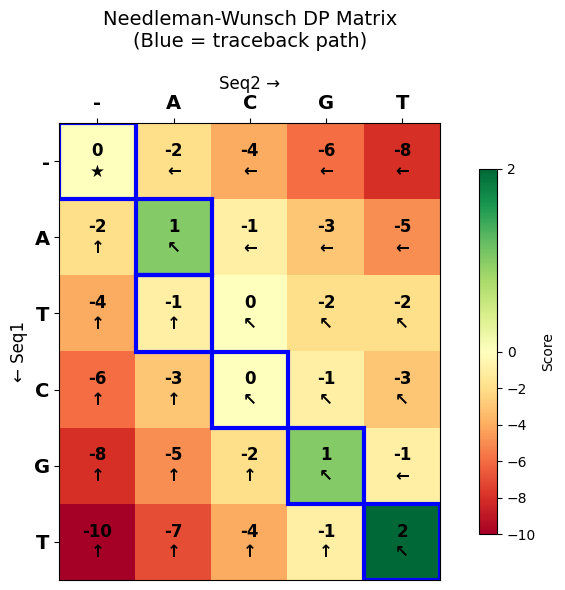

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Color map
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=score_matrix.min(), vcenter=0, vmax=score_matrix.max())

im = ax.imshow(score_matrix, cmap=cmap, norm=norm)

# Labels
col_labels = ['-'] + list(seq2)
row_labels = ['-'] + list(seq1)
ax.set_xticks(range(cols))
ax.set_xticklabels(col_labels, fontsize=14, fontweight='bold')
ax.set_yticks(range(rows))
ax.set_yticklabels(row_labels, fontsize=14, fontweight='bold')

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Seq2 →", fontsize=12)
ax.set_ylabel("← Seq1", fontsize=12)

# Annotate each cell with score and direction arrow
arrow_map = {'D': '↖', 'U': '↑', 'L': '←', '*': '★'}
for i in range(rows):
    for j in range(cols):
        score_val = score_matrix[i][j]
        arrow = arrow_map.get(traceback[i][j], '')
        ax.text(j, i, f"{score_val}\n{arrow}", ha='center', va='center',
                fontsize=12, fontweight='bold')

# Highlight the traceback path
i, j = len(seq1), len(seq2)
path_cells = [(i, j)]
while i > 0 or j > 0:
    d = traceback[i][j]
    if d == 'D':
        i -= 1; j -= 1
    elif d == 'U':
        i -= 1
    elif d == 'L':
        j -= 1
    path_cells.append((i, j))

for (pi, pj) in path_cells:
    rect = plt.Rectangle((pj - 0.5, pi - 0.5), 1, 1,
                          linewidth=3, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)

plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
ax.set_title("Needleman-Wunsch DP Matrix\n(Blue = traceback path)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Part 5: Why Brute Force Fails

How many possible alignments exist for two sequences of length `n`? It grows **exponentially**. Let's compare brute force vs DP.

In [ ]:
from math import comb

def num_possible_alignments(m, n):
    """
    The number of possible global alignments of sequences of length m and n
    is the sum over k (number of gaps) of combinatorial terms.
    A rough approximation: central Delannoy numbers, which grow exponentially.
    For simplicity, we compute it as sum of C(m+n-k, m) * ... but a good
    upper bound is C(2n, n) for equal-length sequences, which grows as 4^n.
    """
    # Exact count using the recursive formula:
    # D(i,j) = D(i-1,j-1) + D(i-1,j) + D(i,j-1), D(0,j)=1, D(i,0)=1
    D = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        D[i][0] = 1
    for j in range(n + 1):
        D[0][j] = 1
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            D[i][j] = D[i - 1][j - 1] + D[i - 1][j] + D[i][j - 1]
    return D[m][n]

print("Sequence lengths → Number of possible alignments vs DP cells\n")
print(f"{'Length':>8} {'Possible Alignments':>25} {'DP Cells (n²)':>15}")
print("-" * 52)
for length in [3, 5, 10, 15, 20, 50]:
    n_align = num_possible_alignments(length, length)
    dp_cells = (length + 1) ** 2
    print(f"{length:>8} {n_align:>25,} {dp_cells:>15,}")

print("\n☝️ For length 20: millions of possible alignments, but only 441 DP cells!")
print("  For length 50: the number of alignments is astronomical.")
print("  DP makes this tractable by reusing overlapping subproblem solutions.")

Sequence lengths → Number of possible alignments vs DP cells

  Length       Possible Alignments   DP Cells (n²)
----------------------------------------------------
       3                        63              16
       5                     1,683              36
      10                 8,097,453             121
      15            44,642,381,823             256
      20       260,543,813,797,441             441
      50 15,310,086,199,495,855,930,932,559,804,210,504,653           2,601

☝️ For length 20: millions of possible alignments, but only 441 DP cells!
  For length 50: the number of alignments is astronomical.
  DP makes this tractable by reusing overlapping subproblem solutions.


## Part 6: Try It Yourself!

Change the sequences below and re-run the alignment. Try:
- Two identical sequences
- Two completely different sequences
- Sequences of very different lengths
- Different scoring parameters

**Questions to think about:**
1. What happens when you make the gap penalty less severe (e.g., -1)?
2. What happens when you make it more severe (e.g., -5)?
3. Can you get multiple equally-good alignments? (Hint: ties in the max)

Seq1: AGTACGCA
        ||x|| 
Seq2: --TATGC-
Score: -3



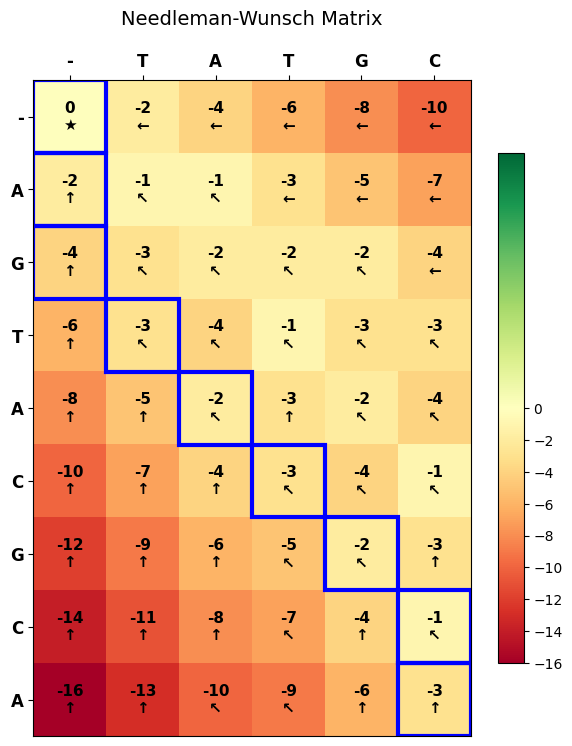

In [ ]:
# ✏️ CHANGE THESE AND RE-RUN!
SEQ1 = "AGTACGCA"
SEQ2 = "TATGC"

MATCH = 1
MISMATCH = -1
GAP = -2

# ---------- Full pipeline in one cell ----------

def needleman_wunsch(s1, s2, match, mismatch, gap):
    r, c = len(s1) + 1, len(s2) + 1
    S = np.zeros((r, c), dtype=int)
    T = np.full((r, c), '', dtype=object)

    for i in range(r):
        S[i][0] = i * gap
        T[i][0] = 'U'
    for j in range(c):
        S[0][j] = j * gap
        T[0][j] = 'L'
    T[0][0] = '*'

    for i in range(1, r):
        for j in range(1, c):
            d = S[i-1][j-1] + (match if s1[i-1] == s2[j-1] else mismatch)
            u = S[i-1][j] + gap
            l = S[i][j-1] + gap
            best = max(d, u, l)
            S[i][j] = best
            if best == d:
                T[i][j] = 'D'
            elif best == u:
                T[i][j] = 'U'
            else:
                T[i][j] = 'L'
    return S, T

def do_traceback(s1, s2, T):
    a1, a2 = [], []
    i, j = len(s1), len(s2)
    while i > 0 or j > 0:
        if T[i][j] == 'D':
            a1.append(s1[i-1]); a2.append(s2[j-1]); i -= 1; j -= 1
        elif T[i][j] == 'U':
            a1.append(s1[i-1]); a2.append('-'); i -= 1
        else:
            a1.append('-'); a2.append(s2[j-1]); j -= 1
    return ''.join(reversed(a1)), ''.join(reversed(a2))

# Run it
S, T = needleman_wunsch(SEQ1, SEQ2, MATCH, MISMATCH, GAP)
a1, a2 = do_traceback(SEQ1, SEQ2, T)

# Display
match_line = ''.join('|' if x == y else (' ' if '-' in (x, y) else 'x') for x, y in zip(a1, a2))
print(f"Seq1: {a1}")
print(f"      {match_line}")
print(f"Seq2: {a2}")
print(f"Score: {S[-1][-1]}\n")

# Visualize
fig, ax = plt.subplots(figsize=(max(6, len(SEQ2)), max(5, len(SEQ1))))
norm = mcolors.TwoSlopeNorm(vmin=S.min(), vcenter=0, vmax=max(S.max(), 1))
im = ax.imshow(S, cmap=plt.cm.RdYlGn, norm=norm)
ax.set_xticks(range(len(SEQ2)+1)); ax.set_xticklabels(['-'] + list(SEQ2), fontsize=12, fontweight='bold')
ax.set_yticks(range(len(SEQ1)+1)); ax.set_yticklabels(['-'] + list(SEQ1), fontsize=12, fontweight='bold')
ax.xaxis.set_ticks_position('top')
arrow_map = {'D': '↖', 'U': '↑', 'L': '←', '*': '★'}
for i in range(len(SEQ1)+1):
    for j in range(len(SEQ2)+1):
        ax.text(j, i, f"{S[i][j]}\n{arrow_map.get(T[i][j],'')}", ha='center', va='center', fontsize=11, fontweight='bold')

# Traceback path
i, j = len(SEQ1), len(SEQ2)
while i > 0 or j > 0:
    rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, lw=3, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)
    d = T[i][j]
    if d == 'D': i -= 1; j -= 1
    elif d == 'U': i -= 1
    else: j -= 1
rect = plt.Rectangle((0-0.5, 0-0.5), 1, 1, lw=3, edgecolor='blue', facecolor='none')
ax.add_patch(rect)

plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Needleman-Wunsch Matrix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 📝 Summary

| Concept | In Fibonacci | In Sequence Alignment |
|---|---|---|
| **Optimal Substructure** | `F(n)` is built from `F(n-1)` + `F(n-2)` | `Score(i,j)` is built from `Score(i-1,j-1)`, `Score(i-1,j)`, `Score(i,j-1)` |
| **Overlapping Subproblems** | `F(3)` is needed by both `F(4)` and `F(5)` | `Score(2,3)` is needed by `Score(3,3)`, `Score(2,4)`, and `Score(3,4)` |
| **Table** | 1D array of size `n` | 2D matrix of size `(m+1) × (n+1)` |
| **Complexity** | O(n) instead of O(2ⁿ) | O(mn) instead of exponential |

**Key takeaway**: Dynamic programming turns an exponential brute-force search into a polynomial-time table-filling exercise. Needleman-Wunsch guarantees the **mathematically optimal** global alignment, not an approximation.

---

## Part 7: Smith-Waterman (Local Alignment)

Needleman-Wunsch finds the best **global** alignment — it aligns the sequences end-to-end. But what if we only care about the **best matching region** within two longer sequences?

For example, maybe two long DNA sequences share a conserved domain in the middle but are completely different at the ends. Forcing a global alignment would penalize all those mismatches at the boundaries and hide the important local similarity.

**Smith-Waterman** solves this. It finds the optimal **local** alignment — the highest-scoring subsequence pair.

### What Changes from Needleman-Wunsch?

| | Needleman-Wunsch (Global) | Smith-Waterman (Local) |
|---|---|---|
| **Initialization** | First row/col filled with cumulative gap penalties | First row/col filled with **0** |
| **Recurrence** | `max(diag, up, left)` | `max(diag, up, left, `**0**`)` |
| **Traceback starts at** | Bottom-right corner | Cell with the **highest score** anywhere in matrix |
| **Traceback ends at** | Top-left corner (0,0) | Any cell with score **0** |

The crucial difference is that extra **zero** in the recurrence. It means: "if all options are negative, just start fresh here." This allows the algorithm to ignore bad regions and focus on the best local match.

The two key DP properties still hold:
- **Optimal substructure**: the best local alignment ending at position `(i,j)` is built from the best local alignments at neighboring cells.
- **Overlapping subproblems**: the same `(i,j)` cells are reused by multiple larger subproblems, and we store them in the table.

### Step 1: Initialize the Smith-Waterman matrix

Unlike Needleman-Wunsch, the first row and first column are all **zeros**. This means there's no penalty for starting the alignment anywhere — the algorithm is free to pick the best starting point.

In [ ]:
import numpy as np

# Sequences — notice they share a conserved region in the middle
seq1_local = "GGAATCGT"
seq2_local = "XXTCGYY"

# Scoring
match_score_l = 2
mismatch_score_l = -1
gap_penalty_l = -2

rows_l = len(seq1_local) + 1
cols_l = len(seq2_local) + 1

# Initialize — ALL ZEROS (this is the key difference!)
sw_matrix = np.zeros((rows_l, cols_l), dtype=int)
sw_traceback = np.full((rows_l, cols_l), '', dtype=object)

# First row and column stay 0 — no gap penalty for "not yet started"
for i in range(rows_l):
    sw_traceback[i][0] = '*'
for j in range(cols_l):
    sw_traceback[0][j] = '*'

print("Sequences:")
print(f"  Seq1: {seq1_local}")
print(f"  Seq2: {seq2_local}")
print(f"\nScoring: match={match_score_l}, mismatch={mismatch_score_l}, gap={gap_penalty_l}")
print(f"\nInitialized matrix (all zeros):\n{sw_matrix}")

Sequences:
  Seq1: GGAATCGT
  Seq2: XXTCGYY

Scoring: match=2, mismatch=-1, gap=-2

Initialized matrix (all zeros):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


### Step 2: Fill the matrix

The recurrence is almost identical to Needleman-Wunsch, but we add a **fourth option**: zero. If all three directions give a negative score, the cell becomes 0, meaning "no good local alignment ends here — start fresh."

$$
S(i,j) = \max\begin{cases}
S(i-1, j-1) + \text{match/mismatch} & \text{(diagonal)}\\
S(i-1, j) + \text{gap penalty} & \text{(up)}\\
S(i, j-1) + \text{gap penalty} & \text{(left)}\\
0 & \text{(start over)}
\end{cases}
$$

In [ ]:
# Fill the Smith-Waterman matrix
max_score = 0
max_pos = (0, 0)

for i in range(1, rows_l):
    for j in range(1, cols_l):
        # Diagonal: match or mismatch
        if seq1_local[i - 1] == seq2_local[j - 1]:
            diag = sw_matrix[i - 1][j - 1] + match_score_l
        else:
            diag = sw_matrix[i - 1][j - 1] + mismatch_score_l

        up = sw_matrix[i - 1][j] + gap_penalty_l
        left = sw_matrix[i][j - 1] + gap_penalty_l

        # THE KEY DIFFERENCE: take max with 0
        best = max(diag, up, left, 0)
        sw_matrix[i][j] = best

        # Track direction for traceback
        if best == 0:
            sw_traceback[i][j] = '*'      # restart — no traceback from here
        elif best == diag:
            sw_traceback[i][j] = 'D'
        elif best == up:
            sw_traceback[i][j] = 'U'
        else:
            sw_traceback[i][j] = 'L'

        # Track the global maximum
        if best > max_score:
            max_score = best
            max_pos = (i, j)

print("Filled Smith-Waterman matrix:")
print(sw_matrix)
print(f"\nHighest score: {max_score} at position {max_pos}")
print(f"  (seq1[{max_pos[0]}] = '{seq1_local[max_pos[0]-1]}', seq2[{max_pos[1]}] = '{seq2_local[max_pos[1]-1]}')")
print(f"\nTraceback directions:")
print(sw_traceback)

Filled Smith-Waterman matrix:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 0 2 1 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0]
 [0 0 0 0 4 2 0 0]
 [0 0 0 0 2 6 4 2]
 [0 0 0 2 0 4 5 3]]

Highest score: 6 at position (7, 5)
  (seq1[7] = 'G', seq2[5] = 'G')

Traceback directions:
[['*' '*' '*' '*' '*' '*' '*' '*']
 ['*' '*' '*' '*' '*' 'D' '*' '*']
 ['*' '*' '*' '*' '*' 'D' 'D' '*']
 ['*' '*' '*' '*' '*' '*' 'D' '*']
 ['*' '*' '*' '*' '*' '*' '*' '*']
 ['*' '*' '*' 'D' '*' '*' '*' '*']
 ['*' '*' '*' '*' 'D' 'L' '*' '*']
 ['*' '*' '*' '*' 'U' 'D' 'L' 'L']
 ['*' '*' '*' 'D' '*' 'U' 'D' 'D']]


### Step 3: Traceback

In Smith-Waterman, the traceback is different from Needleman-Wunsch:
- **Start**: at the cell with the **highest score** (not the bottom-right corner)
- **Stop**: when we hit a cell with score **0** (not necessarily the top-left corner)

This is what gives us the **local** alignment — it automatically trims away the bad regions at the edges.

In [ ]:
# Smith-Waterman Traceback
aligned_s1 = []
aligned_s2 = []

i, j = max_pos
traceback_path = [(i, j)]

while sw_matrix[i][j] != 0 and i > 0 and j > 0:
    direction = sw_traceback[i][j]

    if direction == 'D':
        aligned_s1.append(seq1_local[i - 1])
        aligned_s2.append(seq2_local[j - 1])
        i -= 1
        j -= 1
    elif direction == 'U':
        aligned_s1.append(seq1_local[i - 1])
        aligned_s2.append('-')
        i -= 1
    elif direction == 'L':
        aligned_s1.append('-')
        aligned_s2.append(seq2_local[j - 1])
        j -= 1
    else:
        break

    traceback_path.append((i, j))

# Reverse
aligned_s1 = ''.join(reversed(aligned_s1))
aligned_s2 = ''.join(reversed(aligned_s2))

match_line = ''
for a, b in zip(aligned_s1, aligned_s2):
    if a == b:
        match_line += '|'
    elif a == '-' or b == '-':
        match_line += ' '
    else:
        match_line += 'x'

print("=" * 45)
print("   OPTIMAL LOCAL ALIGNMENT (Smith-Waterman)")
print("=" * 45)
print(f"  Seq1: {aligned_s1}")
print(f"        {match_line}")
print(f"  Seq2: {aligned_s2}")
print(f"\n  Score: {max_score}")
print(f"  Region in Seq1: positions {traceback_path[-1][0]}-{traceback_path[0][0]}")
print(f"  Region in Seq2: positions {traceback_path[-1][1]}-{traceback_path[0][1]}")
print("=" * 45)

   OPTIMAL LOCAL ALIGNMENT (Smith-Waterman)
  Seq1: TCG
        |||
  Seq2: TCG

  Score: 6
  Region in Seq1: positions 4-7
  Region in Seq2: positions 2-5


### Step 4: Visualize the Smith-Waterman Matrix

Notice how many cells are **zero** — these are regions where no good local alignment exists. The algorithm naturally ignores them.

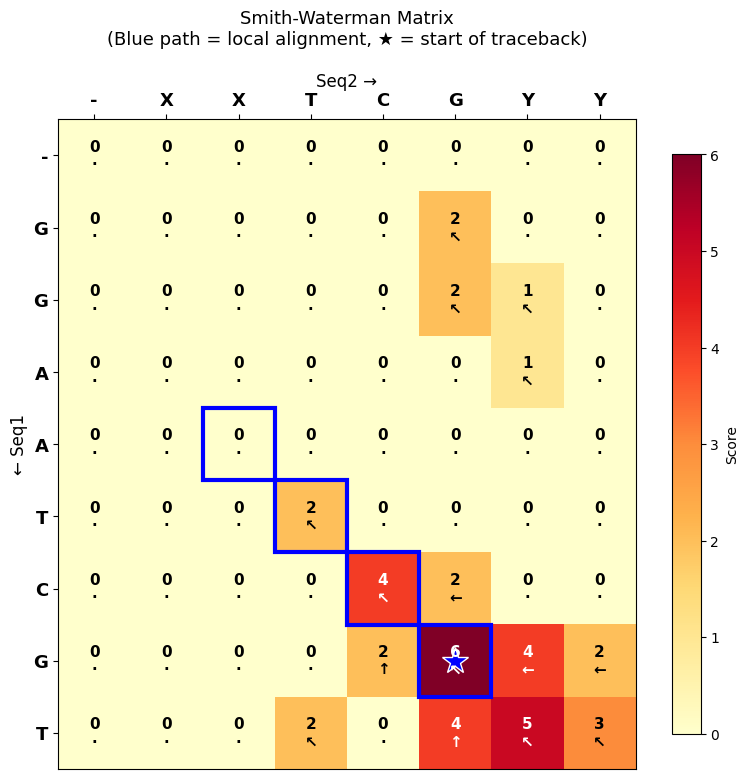

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(max(7, len(seq2_local)+1), max(6, len(seq1_local)+1)))

vmax = max(sw_matrix.max(), 1)
im = ax.imshow(sw_matrix, cmap='YlOrRd', vmin=0, vmax=vmax)

# Labels
col_labels = ['-'] + list(seq2_local)
row_labels = ['-'] + list(seq1_local)
ax.set_xticks(range(cols_l))
ax.set_xticklabels(col_labels, fontsize=13, fontweight='bold')
ax.set_yticks(range(rows_l))
ax.set_yticklabels(row_labels, fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Seq2 →", fontsize=12)
ax.set_ylabel("← Seq1", fontsize=12)

# Annotate
arrow_map = {'D': '↖', 'U': '↑', 'L': '←', '*': '·'}
for i in range(rows_l):
    for j in range(cols_l):
        val = sw_matrix[i][j]
        arrow = arrow_map.get(sw_traceback[i][j], '')
        color = 'white' if val > vmax * 0.6 else 'black'
        ax.text(j, i, f"{val}\n{arrow}", ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

# Highlight traceback path
for (pi, pj) in traceback_path:
    rect = plt.Rectangle((pj - 0.5, pi - 0.5), 1, 1,
                          linewidth=3, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)

# Star the max cell
ax.plot(max_pos[1], max_pos[0], marker='*', markersize=20,
        color='blue', markeredgecolor='white', markeredgewidth=1)

plt.colorbar(im, ax=ax, shrink=0.7, label='Score')
ax.set_title("Smith-Waterman Matrix\n(Blue path = local alignment, ★ = start of traceback)",
             fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## Part 8: Side-by-Side Comparison

Let's run **both** algorithms on the same sequences and see how their results differ.

In [ ]:
# Side-by-side comparison on the same sequences

COMP_SEQ1 = "TGTTACGG"
COMP_SEQ2 = "GGTTGACTA"

MATCH_C = 2
MISMATCH_C = -1
GAP_C = -2

# ---- Needleman-Wunsch (Global) ----
def run_nw(s1, s2, match, mismatch, gap):
    r, c = len(s1) + 1, len(s2) + 1
    S = np.zeros((r, c), dtype=int)
    T = np.full((r, c), '', dtype=object)
    for i in range(r): S[i][0] = i * gap; T[i][0] = 'U'
    for j in range(c): S[0][j] = j * gap; T[0][j] = 'L'
    T[0][0] = '*'
    for i in range(1, r):
        for j in range(1, c):
            d = S[i-1][j-1] + (match if s1[i-1] == s2[j-1] else mismatch)
            u = S[i-1][j] + gap
            l = S[i][j-1] + gap
            best = max(d, u, l)
            S[i][j] = best
            T[i][j] = 'D' if best == d else ('U' if best == u else 'L')
    # traceback
    a1, a2 = [], []
    i, j = len(s1), len(s2)
    while i > 0 or j > 0:
        if T[i][j] == 'D': a1.append(s1[i-1]); a2.append(s2[j-1]); i -= 1; j -= 1
        elif T[i][j] == 'U': a1.append(s1[i-1]); a2.append('-'); i -= 1
        else: a1.append('-'); a2.append(s2[j-1]); j -= 1
    return S, ''.join(reversed(a1)), ''.join(reversed(a2))

# ---- Smith-Waterman (Local) ----
def run_sw(s1, s2, match, mismatch, gap):
    r, c = len(s1) + 1, len(s2) + 1
    S = np.zeros((r, c), dtype=int)
    T = np.full((r, c), '', dtype=object)
    for i in range(r): T[i][0] = '*'
    for j in range(c): T[0][j] = '*'
    mx, mp = 0, (0, 0)
    for i in range(1, r):
        for j in range(1, c):
            d = S[i-1][j-1] + (match if s1[i-1] == s2[j-1] else mismatch)
            u = S[i-1][j] + gap
            l = S[i][j-1] + gap
            best = max(d, u, l, 0)
            S[i][j] = best
            if best == 0: T[i][j] = '*'
            elif best == d: T[i][j] = 'D'
            elif best == u: T[i][j] = 'U'
            else: T[i][j] = 'L'
            if best > mx: mx = best; mp = (i, j)
    # traceback
    a1, a2 = [], []
    i, j = mp
    while S[i][j] != 0 and i > 0 and j > 0:
        if T[i][j] == 'D': a1.append(s1[i-1]); a2.append(s2[j-1]); i -= 1; j -= 1
        elif T[i][j] == 'U': a1.append(s1[i-1]); a2.append('-'); i -= 1
        elif T[i][j] == 'L': a1.append('-'); a2.append(s2[j-1]); j -= 1
        else: break
    return S, ''.join(reversed(a1)), ''.join(reversed(a2))

nw_S, nw_a1, nw_a2 = run_nw(COMP_SEQ1, COMP_SEQ2, MATCH_C, MISMATCH_C, GAP_C)
sw_S, sw_a1, sw_a2 = run_sw(COMP_SEQ1, COMP_SEQ2, MATCH_C, MISMATCH_C, GAP_C)

def match_str(a, b):
    return ''.join('|' if x == y else (' ' if '-' in (x, y) else 'x') for x, y in zip(a, b))

print("=" * 55)
print("   NEEDLEMAN-WUNSCH (GLOBAL ALIGNMENT)")
print("=" * 55)
print(f"  Seq1: {nw_a1}")
print(f"        {match_str(nw_a1, nw_a2)}")
print(f"  Seq2: {nw_a2}")
print(f"  Score: {nw_S[-1][-1]}")
print()
print("=" * 55)
print("   SMITH-WATERMAN (LOCAL ALIGNMENT)")
print("=" * 55)
print(f"  Seq1: {sw_a1}")
print(f"        {match_str(sw_a1, sw_a2)}")
print(f"  Seq2: {sw_a2}")
print(f"  Score: {sw_S.max()}")
print()

   NEEDLEMAN-WUNSCH (GLOBAL ALIGNMENT)
  Seq1: TGTT-ACGG
        x||| ||xx
  Seq2: GGTTGACTA
  Score: 5

   SMITH-WATERMAN (LOCAL ALIGNMENT)
  Seq1: GTT-AC
        ||| ||
  Seq2: GTTGAC
  Score: 8



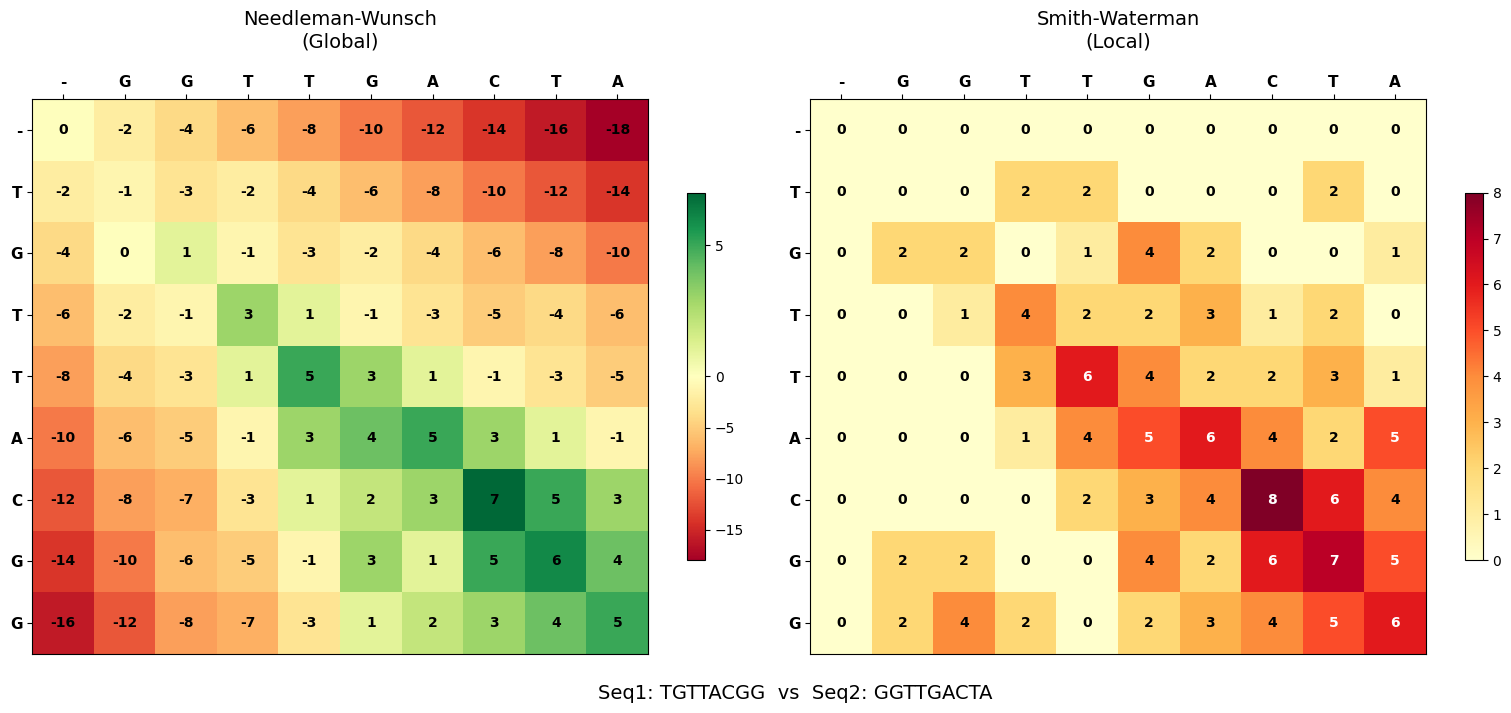

In [ ]:
# Visualize both matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (matrix, title, cmap_name) in enumerate([
    (nw_S, "Needleman-Wunsch\n(Global)", "RdYlGn"),
    (sw_S, "Smith-Waterman\n(Local)", "YlOrRd")
]):
    ax = axes[idx]
    r, c = matrix.shape
    col_labels = ['-'] + list(COMP_SEQ2)
    row_labels = ['-'] + list(COMP_SEQ1)

    if cmap_name == "RdYlGn":
        norm = mcolors.TwoSlopeNorm(vmin=matrix.min(), vcenter=0, vmax=max(matrix.max(), 1))
        im = ax.imshow(matrix, cmap=cmap_name, norm=norm)
    else:
        im = ax.imshow(matrix, cmap=cmap_name, vmin=0, vmax=max(matrix.max(), 1))

    ax.set_xticks(range(c))
    ax.set_xticklabels(col_labels, fontsize=11, fontweight='bold')
    ax.set_yticks(range(r))
    ax.set_yticklabels(row_labels, fontsize=11, fontweight='bold')
    ax.xaxis.set_ticks_position('top')

    for i in range(r):
        for j in range(c):
            val = matrix[i][j]
            color = 'white' if (cmap_name == "YlOrRd" and val > matrix.max() * 0.6) else 'black'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, shrink=0.6)
    ax.set_title(title, fontsize=14, pad=20)

plt.suptitle(f"Seq1: {COMP_SEQ1}  vs  Seq2: {COMP_SEQ2}", fontsize=14, y=0.02)
plt.tight_layout()
plt.show()

In [ ]:
## Part 9: When to Use Which?

| Scenario | Use | Why |
|---|---|---|
| Compare two full genes of similar length | **Needleman-Wunsch** (Global) | You want end-to-end alignment |
| Find a conserved motif in a long sequence | **Smith-Waterman** (Local) | You only care about the best matching region |
| BLAST search against a database | **Smith-Waterman** (Local) | Database sequences may only share a domain |
| Compare two homologous proteins | **Needleman-Wunsch** (Global) | Full-length comparison reveals insertions/deletions |
| Detect a short primer in a genome | **Smith-Waterman** (Local) | Primer is much shorter than the genome |

---

## Part 10: Try Both Yourself!

Modify the sequences and parameters below. Look at how global vs. local alignment behave differently.

## 📝 Final Summary

| Concept | Fibonacci | Needleman-Wunsch (Global) | Smith-Waterman (Local) |
|---|---|---|---|
| **Problem type** | Number sequence | End-to-end alignment | Best local region |
| **Optimal substructure** | `F(n) = F(n-1) + F(n-2)` | Best of diag/up/left | Best of diag/up/left/**0** |
| **Overlapping subproblems** | `F(k)` reused by `F(k+1)` and `F(k+2)` | `S(i,j)` reused by 3 neighbors | Same as NW |
| **Table** | 1D array | 2D matrix | 2D matrix |
| **Initialization** | `F(0)=0, F(1)=1` | Cumulative gap penalties | All zeros |
| **Answer location** | `table[n]` | Bottom-right corner | Maximum anywhere in matrix |
| **Traceback ends** | — | At `(0,0)` | At any cell with score 0 |
| **Complexity** | O(n) | O(m × n) | O(m × n) |

### The DP Mindset
1. **Define** the subproblem (what does cell `(i,j)` represent?)
2. **Write** the recurrence (how does `(i,j)` depend on smaller subproblems?)
3. **Initialize** the base cases (first row, first column)
4. **Fill** the table (bottom-up, so dependencies are always ready)
5. **Traceback** to recover the solution (not just the score)

This same pattern appears everywhere in bioinformatics: multiple sequence alignment, RNA structure prediction, gene finding, and more.